In [209]:
import numpy as np

from scipy.linalg import block_diag

import matplotlib.pyplot as plt
import umap
from sklearn.cluster import DBSCAN

import argparse
import numpy
import torch

from datasets import load_dataloaders, load_mnist
from model.hopfield.network import DeepHopfieldEnergy
from model.function.network import Network
from model.function.cost import SquaredError
from model.hopfield.minimizer import FixedPointMinimizer
from training.sgd import EquilibriumProp, Backprop, AugmentedFunction
from training.epoch import Trainer, Evaluator
from training.monitor import Monitor, Optimizer

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons

In [210]:
def hidden_hopfield_energy(w, n, b, activation):
    interaction_term = np.einsum('ijk,jik->jk', activation(np.transpose(n[1:, :, :], (1, 0, 2))), w @ activation(n[:-1, :, :]))
    norm_term = 0.5*np.sum(np.square(n))
    bias_term = np.einsum('ijk, ijk -> ik', b, activation(n))

    return norm_term - np.sum(interaction_term) - np.sum(bias_term)

def hidden_hopfield_grad(w, n, b, activation, activation_derivative):
    act_n = activation(n[:, :, 0])  # Shape (num_layers, num_neurons)
    act_deriv_n = activation_derivative(n[:, :, 0])  # Shape (num_layers, num_neurons
    grad = np.zeros_like(n)
    grad[:, :, 0] = n[:, :, 0] - (act_deriv_n[:, :] * b[:, :, 0])
    pre_term = np.einsum('bji,bj->bi', w[:, :, :], act_n[:-1, :])
    post_term = np.einsum('bij,bj->bi', w[:, :, :], act_n[1:, :])
    grad[1:, :, 0] -= activation_derivative(n[1:, :, 0]) * pre_term
    grad[:-1, :, 0] -= activation_derivative(n[:-1, :, 0]) * post_term

    return grad

def interaction_energy(pre_n, post_n, w, pre_b, hidden_activation, pre_activation):
    int_term = pre_activation(pre_n).T @ w @ hidden_activation(post_n)
    b_term = pre_b.T @ pre_activation(pre_n)
    norm_term = 0.5*np.sum(np.square(pre_n))

    return norm_term - int_term[0] + b_term[0,0]

def interaction_grad(pre_n, post_n, w, pre_b, hidden_activation, hidden_activation_derivative, pre_activation, pre_activation_derivative, freeze_pre):

    post_grad = -1.0*hidden_activation_derivative(post_n) * ((w.T @ pre_activation(pre_n))[:,0])

    if freeze_pre:
        pre_grad = np.zeros_like(pre_n)
    else:
        pre_grad = pre_n[:,0] - (1.0*pre_activation_derivative(pre_n)[:,0]  * (w @ hidden_activation(post_n) + pre_b[:,0]))

    return pre_grad, post_grad

In [211]:
def random_symmetric_matrix(N, mu, sigma):
    M = np.random.lognormal(mean=mu, sigma=sigma, size=(N, N))
    signs = np.random.choice([-1, 1], size=(N, N))
    M *= signs
    return M

In [212]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_prime(x):
    return np.exp(x) / ((1 + np.exp(x))**2)

def ReLU(x):
    return np.clip(x, 0., 1.)

def ReLU_prime(x):
    return np.where(x > 0, 1, 0)

def linear(x):
    return x

def linear_prime(x):
    return np.ones_like(x)

def block_diagonal_matrix(matrices):
    return block_diag(*matrices)

def get_diagonal_blocks(matrix, L):
    N = np.shape(matrix)[0]
    block_size = N // L
    diagonal_blocks = []

    for i in range(L): 
        row_start = i * block_size
        row_end = row_start + block_size
        col_start = i * block_size
        col_end = col_start + block_size

        diagonal_block = matrix[row_start:row_end, col_start:col_end]
        diagonal_blocks.append(diagonal_block)

    return diagonal_blocks

def split_array(arr, L):
    n_p_layer = int(np.shape(arr)[0] / L)
    return [arr[i:i + n_p_layer] for i in range(0, len(arr), n_p_layer)]



In [213]:

def hopfield_one_visible(w_h, h, b_h, act_h, x, w_x, b_x, act_x, con = 0):

    return hidden_hopfield_energy(w_h, h, b_h, act_h) + interaction_energy(x, h[con, :, 0], w_x, b_x, act_h, act_x)

def hopfield_two_visible(w, n, b, act, con_x = 0, con_y = -1):
    w_h, w_x, w_y = w
    h, x, y = n
    b_h, b_x, b_y = b
    act_h, act_x, act_y = act
    energy = hidden_hopfield_energy(w_h, h, b_h, act_h)  + interaction_energy(x, h[con_x, :, 0], w_x, b_x, act_h, act_x) + interaction_energy(y, h[con_y, :, 0], w_y, b_y, act_h, act_y)
    return energy

def hopfield_grad_two_visible(w, n, b, act, act_prime, con_x, con_y, freeze_x, freeze_y):
    w_h, w_x, w_y = w
    h, x, y = n
    b_h, b_x, b_y = b
    act_h, act_x, act_y = act
    act_prime_h, act_prime_x, act_prime_y = act_prime
    h_grad = hidden_hopfield_grad(w_h, h, b_h, act_h, act_prime_h)
    x_grad, xh_grad = interaction_grad(x, h[con_x, :, 0], w_x, b_x, act_h, act_prime_h, act_x, act_prime_x, freeze_x)
    y_grad, yh_grad = interaction_grad(y, h[con_y, :, 0], w_y, b_y, act_h, act_prime_h, act_y, act_prime_y, freeze_y)
    
    h_grad[con_x, :, 0] +=  xh_grad
    h_grad[con_y, :, 0] +=  yh_grad

    return h_grad, x_grad, y_grad



In [214]:
class InferenceMachine():

    def __init__(self,w,b,act,act_prime) -> None:
        self.w = w
        self.b = b
        self.act = act
        self.act_prime = act_prime

    def hopfield_2vis_grad_fn(self, h_var, x_var, y_var, con_x, con_y, freeze_x, freeze_y):
        n_var = h_var, x_var, y_var
        return hopfield_grad_two_visible(self.w, n_var, self.b, self.act, self.act_prime, con_x, con_y, freeze_x, freeze_y)

    def hopfield_2vis_energy_fn(self, h_var, x_var, y_var):
        n_var = h_var, x_var, y_var
        return hopfield_two_visible(self.w, n_var, self.b, self.act, con_x = 0, con_y = -1)
    
    def minimize(self, n_init, num_steps, dt, c_x = 0, c_y = -1, f_x = True, f_y = False):
        h_init, x_init, y_init = n_init
        h_state = h_init
        x_state = x_init
        y_state = y_init
        energy = []
        for i in range(num_steps):
            grad_h, grad_x, grad_y = self.hopfield_2vis_grad_fn(h_state, x_state, y_state, c_x, c_y, f_x, f_y)
            grad_y = grad_y[:, np.newaxis]
            h_state -= dt*grad_h + np.random.normal(loc=0, scale=0.2, size=h_state.shape)
            x_state -= dt*grad_x 
            y_state -= dt*grad_y
            energy.append(self.hopfield_2vis_energy_fn(h_state, x_state, y_state))

        return h_state, x_state, y_state, energy
    
class JointMinimization():

    def __init__(self, num_layer, n_per_layer) -> None:
        self.num = x
        self.y = y

    def 



In [215]:
loaded_data = np.load("TwoMoons_3L32N25E.npz")
for key in loaded_data.keys():
    print(key)
    print(np.shape(loaded_data[key]))


weights = np.stack([loaded_data['DenseWeight_5'], loaded_data['DenseWeight_6']], axis=0)
bias = np.stack([loaded_data['Bias_6'].reshape(32,1), loaded_data['Bias_7'].reshape(32,1), loaded_data['Bias_8'].reshape(32,1)], axis=0)

x_weights= loaded_data['DenseWeight_4']
y_weights= loaded_data['DenseWeight_7'].T

x_bias = np.array([[0.0, 0.0]]).T
y_bias = loaded_data['Bias_9'].reshape(2,1)

Bias_6
(32,)
Bias_7
(32,)
Bias_8
(32,)
Bias_9
(2,)
DenseWeight_4
(2, 32)
DenseWeight_5
(32, 32)
DenseWeight_6
(32, 32)
DenseWeight_7
(32, 2)


In [216]:
w = weights, x_weights, y_weights
b = bias, x_bias, y_bias
act = ReLU, linear, linear
act_prime = ReLU_prime, linear_prime, linear_prime

machine = InferenceMachine(w,b,act, act_prime)

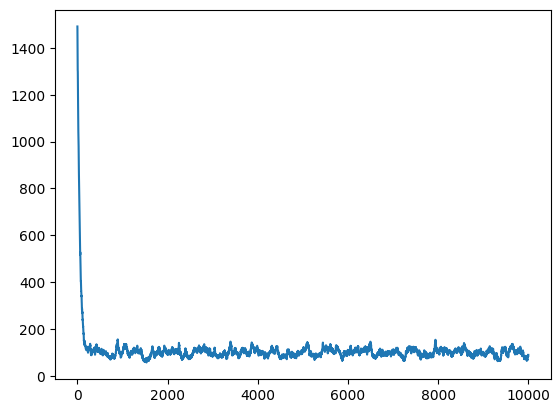

In [217]:
h_init = np.random.uniform(-10.0, 10.0, (np.shape(bias)[0], np.shape(bias)[1], 1))
x_init = np.random.uniform(-2.0, 2.0, np.shape(x_bias))
y_init = np.random.uniform(-10.0, 10.0, np.shape(y_bias))

n_init = h_init, x_init, y_init
num_steps = 10000
dt = 0.01
h_eq, x_inp, y_eq, en = machine.minimize(n_init, num_steps, dt)


plt.plot(range(len(en)), en)


In [218]:
num_steps = 1000
dt = 0.01

y_points = []
h_points = []
x_points = []
eq_energy = []

x1 = np.linspace(-3, 3, 50)  # 5 points along x-axis
x2 = np.linspace(-3, 3, 50)  # 5 points along y-axis

X1, X2 = np.meshgrid(x1, x2)
points = [np.array([[X1[i, j]], [X2[i, j]]]) for i in range(X1.shape[0]) for j in range(X1.shape[1])]
data = np.array(points)
num_points = len(points)
print('Number of Data Points:', num_points)
for i, point in enumerate(points):
    h_init = np.zeros(np.shape(bias))
    y_init = np.zeros(np.shape(y_bias))
    n_init = h_init, point, y_init
    h_eq, x_inp, y_eq, en = machine.minimize(n_init, num_steps, dt)
    y_points.append(y_eq)
    h_points.append(h_eq)
    eq_energy.append(en[-1])
    x_points.append(x_inp)
    if i % 100 == 0:
        print(i)

y_points = np.array(y_points)
h_points = np.array(h_points)   
eq_energy = np.array(eq_energy) 
x_points = np.array(x_points)

Number of Data Points: 2500
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400


(2500, 2)


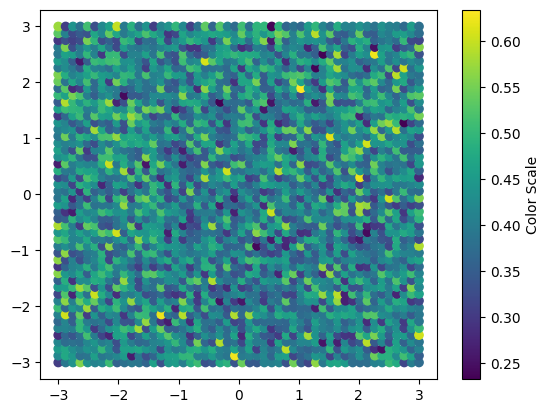

In [220]:
x_points = np.array(points)

array_2d = y_points.squeeze(axis=-1)  
print(np.shape(array_2d))
softmax = np.exp(array_2d) / np.sum(np.exp(array_2d), axis=1, keepdims=True)
class0_probs = softmax[:,0]


sc = plt.scatter(x_points[:,0,0], x_points[:,1,0], c=class0_probs)
plt.colorbar(sc, label="Color Scale")


In [ ]:
n_per_Layer = 32
n_layers = 3

input_size = 2
output_size = 2

weights = np.random.lognormal(0.1, 1.0, (n_layers - 1, n_per_Layer, n_per_Layer))
sign_flip = np.random.choice([1, -1], size=weights.shape)
weights = weights * sign_flip

bias = np.random.lognormal(0.1, 1.0, (n_layers, n_per_Layer, 1))
sign_flip2 = np.random.choice([1, -1], size=bias.shape)
bias = bias * sign_flip2

x_weights = np.random.lognormal(0.1, 1.0, (input_size, n_per_Layer))
sign_flip = np.random.choice([1, -1], size=x_weights.shape)
x_weights = x_weights * sign_flip
x_bias = np.random.lognormal(0.1, 1.0, (input_size, 1))
sign_flip = np.random.choice([1, -1], size=x_bias.shape)
x_bias = x_bias * sign_flip

y_weights = np.random.lognormal(0.1, 1.0, (output_size, n_per_Layer))
sign_flip = np.random.choice([1, -1], size=y_weights.shape)
y_weights = y_weights * sign_flip
y_bias = np.random.lognormal(0.1, 1.0, (output_size, 1))
sign_flip = np.random.choice([1, -1], size=y_bias.shape)
y_bias = y_bias * sign_flip

print(np.shape(x_weights))

In [ ]:
def hamiltonian_grad_fn(n):
    # Use the hopfield_grad_fn to compute the gradient (potential energy gradient)
    return hop_grad_fn(n)

def hamiltonian_monte_carlo(initial_state, num_steps, var, step_size=0.1, num_leapfrog_steps=10):
    state = initial_state
    samples = []
    energy = []

    for i in range(num_steps):
        # 1. Sample momentum from a Gaussian distribution
        momentum = np.random.normal(0, var, size=state.shape)
        
        # 2. Compute the initial energy (potential + kinetic)
        initial_state_energy = hopfield_energy_fn(state)  # Energy from the gradient
        initial_momentum_energy = 0.5 * np.sum(np.einsum('ijk,ijk->ij', momentum, momentum))  # Kinetic energy
        
        # 3. Perform leapfrog integration
        state_new = state.copy()
        momentum_new = momentum.copy()

        # Leapfrog integration
        for _ in range(num_leapfrog_steps):
            # Half step for momentum
            momentum_new -= 0.5 * step_size * hamiltonian_grad_fn(state_new)
            # Full step for state
            state_new += step_size * momentum_new
            # Half step for momentum
            momentum_new -= 0.5 * step_size * hamiltonian_grad_fn(state_new)

        # 4. Compute the new energy (potential + kinetic)
        final_state_energy = hopfield_energy_fn(state_new)
        final_momentum_energy = 0.5 * np.sum(np.einsum('ijk,ijk->ij', momentum_new, momentum_new))

        # 5. Metropolis acceptance step
        energy_diff = (final_state_energy + final_momentum_energy) - (initial_state_energy + initial_momentum_energy)
        acceptance_prob = np.exp(-energy_diff)

        if np.random.rand() < acceptance_prob:
            # Accept the new state
            state = state_new
        
        samples.append(state)
        energy.append(hopfield_energy_fn(state))
        
        if i % 1000 == 0:
            print(i)
    
    return np.array(samples), np.array(energy)

In [ ]:
initial_state = np.random.uniform(-5.0, 5.0, (n_layers, n_per_Layer, 1))
num_steps = 50000
samples = hamiltonian_monte_carlo(initial_state, num_steps, var=5)

samp, energies = samples

umap_model1 = umap.UMAP(n_components=2, random_state=42)
umap1 = umap_model1.fit_transform(samp.squeeze(axis=-1).reshape(np.shape(samp)[0], -1))

fig, ax = plt.subplots()

sc1 = ax.scatter(umap1[:, 0], umap1[:, 1], c=energies, cmap='viridis', alpha=0.7)
cbar1 = fig.colorbar(sc1, ax=ax)
cbar1.set_label("Equilibrium Energy", fontsize=12)
ax.set_title('Equilibrium Energy')

In [ ]:
points = umap1

dbscan = DBSCAN(eps=0.5, min_samples=10)
labels = dbscan.fit_predict(points)

# Plot results
plt.figure(figsize=(10, 6))
unique_labels = set(labels)

# Generate colors
colors = plt.cm.get_cmap("tab10", len(unique_labels))  # Use tab10 colormap

for label in unique_labels:
    cluster_points = points[labels == label]  # Get points belonging to this cluster
    color = 'k' if label == -1 else colors(label)  # Black for noise (-1)
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=5, c=[color], label=f"Cluster {label}" if label != -1 else "Noise")

plt.title("DBSCAN Clustering of 2D Points")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.show()

In [ ]:

from sklearn.manifold import TSNE


np.random.seed(42)
data = samp.squeeze(axis=-1).reshape(np.shape(samp)[0], -1)

# Apply t-SNE (2D reduction)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
data_2d = tsne.fit_transform(data)

# Scatter plot of the t-SNE results
plt.figure(figsize=(8, 6))
plt.scatter(data_2d[:, 0], data_2d[:, 1], s=5, alpha=0.5)  # Small markers for better visibility
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of 100-D Vectors")
plt.show()


In [ ]:
plt.hist(data_2d[:, 1],bins=50)

In [ ]:
for i in range(len(labels)):
    if labels[i] == 0 and labels[i+1] ==1:
        before = samp[i,:,:,0].flatten()
        after = samp[i+1,:,:,0].flatten()

print(np.linalg.norm(before - after))
print(np.linalg.norm(before - samp[0,:,:,0].flatten()))

In [ ]:
def input_output_energy(x, y, internal_energy, w, b, n, activation, in_w, in_b, out_w, out_b):
    int_energy = internal_energy(w, n, b, activation)
    input_interaction = 0.5 * (x.T @ x) - in_b.T @ activation(x) - activation(n[1,:,0]).T @ in_w[:,:] @ activation(x)
    output_interaction = 0.5 * (y.T @ y) - out_b.T @ activation(y) - activation(y).T @ out_w[:,:] @ activation(n[-1,:,0])

    return int_energy + input_interaction + output_interaction


In [ ]:
n_per_Layer = 16
n_layers = 8

weights = np.random.lognormal(0.1, 1.0, (n_layers - 1, n_per_Layer, n_per_Layer))
sign_flip = np.random.choice([1, -1], size=weights.shape)
weights = weights * sign_flip

bias = np.random.lognormal(0.1, 1.0, (n_layers, n_per_Layer, 1))
sign_flip2 = np.random.choice([1, -1], size=bias.shape)
bias = bias * sign_flip2

initial_state = np.random.uniform(-2.0, 2.0, (n_layers, n_per_Layer, 1))


num_classes = 2
dim_data = 2

in_weights = np.random.lognormal(0.1, 1.0, (n_per_Layer, dim_data))
sign_flip = np.random.choice([1, -1], size=in_weights.shape)
in_weights = in_weights * sign_flip

in_bias = np.random.lognormal(0.1, 1.0, (dim_data, 1))
sign_flip2 = np.random.choice([1, -1], size=in_bias.shape)
in_bias = in_bias * sign_flip2

out_weights = np.random.lognormal(0.1, 1.0, (num_classes, n_per_Layer))
sign_flip = np.random.choice([1, -1], size=out_weights.shape)
out_weights = out_weights * sign_flip

out_bias = np.random.lognormal(0.1, 1.0, (num_classes, 1))
sign_flip2 = np.random.choice([1, -1], size=out_bias.shape)
out_bias = out_bias * sign_flip2

initial_state = np.random.uniform(-2.0, 2.0, (n_layers, n_per_Layer, 1))
x_fix = np.random.uniform(-2.0, 2.0, (dim_data, 1))
y_fix = np.array([[1.0,1.0]]).T

def input_energy(x):
    return input_output_energy(x, y_fix, hopfield_energy, weights, bias, initial_state, sigmoid, in_weights, in_bias, out_weights, out_bias)

def output_energy(y):
    return input_output_energy(x_fix, y, hopfield_energy, weights, bias, initial_state, sigmoid, in_weights, in_bias, out_weights, out_bias)

In [ ]:
num_samp = 10000

energy = []
x_batch = np.random.uniform(-10.0, 10.0, (dim_data, num_samp))
print(y_fix)
for j in range(np.shape(x_batch)[-1]):
    
    energy.append(input_energy(x_batch[:,j]))

plt.scatter(x_batch[0,:], x_batch[1,:], c=energy, cmap = 'coolwarm')

In [ ]:

points = umap1

dbscan = DBSCAN(eps=0.5, min_samples=10)
labels = dbscan.fit_predict(points)

# Plot results
plt.figure(figsize=(10, 6))
unique_labels = set(labels)

# Generate colors
colors = plt.cm.get_cmap("tab10", len(unique_labels))  # Use tab10 colormap

for label in unique_labels:
    cluster_points = points[labels == label]  # Get points belonging to this cluster
    color = 'k' if label == -1 else colors(label)  # Black for noise (-1)
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=5, c=[color], label=f"Cluster {label}" if label != -1 else "Noise")

plt.title("DBSCAN Clustering of 2D Points")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.show()


In [ ]:
basin_no = 6

basin_neurons = []

flat_smap = samp.squeeze(axis=-1).reshape(np.shape(samp)[0], -1)

for i, label in enumerate(labels):
    if label == basin_no:
        basin_neurons.append(flat_smap[i, :])

basin_neurons = np.array(basin_neurons)
avg_firing = np.mean(basin_neurons, axis=0)

plt.hist(avg_firing, bins=10)

In [ ]:
plt.hist(energies, bins=50)

In [ ]:
init_neurons = np.random.uniform(n_min, n_max, (n_layers, n_per_Layer, 1))

num_s = 1000
step = 1000

samp = metropolis_hastings(init_neurons, step, num_s)

In [ ]:
def sample(num)

In [ ]:
def hopfield_energy(weight, bias, neuron, num_layers):

    U = 0

    num_neurons = np.shape(neuron)[0]
    if num_neurons % num_layers != 0:
        raise ValueError('Neurons not divisible into Layers')
    else:
        weight_by_layer = get_diagonal_blocks(weight, num_layers)
        bias_by_layer = split_array(bias, num_layers)
        neuron_by_layer = split_array(neuron, num_layers)

    for i in range(len(weight_by_layer)-1):

        w = weight_by_layer[i]
        b = bias_by_layer[i]
        pre_act = sigmoid(neuron_by_layer[i])
        post_act = sigmoid(neuron_by_layer[i+1])

        U += 0.5*(neuron_by_layer[i].T @ neuron_by_layer[i])

        U -= b.T @ pre_act
        U -= pre_act.T @ w @ post_act

    U += 0.5*(neuron_by_layer[-1].T @ neuron_by_layer[-1])
    U -= b.T @ sigmoid(neuron_by_layer[-1])

    return U

def hopfield_grad(weight, bias, neuron, num_layers):

    grad = []

    weight_by_layer = get_diagonal_blocks(weight, num_layers)
    bias_by_layer = split_array(bias, num_layers)
    neuron_by_layer = split_array(neuron, num_layers)

    grad.append(sigmoid_prime(neuron_by_layer[0]) * ((sigmoid(neuron_by_layer[1]).T @ weight_by_layer[0]) - bias_by_layer[0]) - neuron_by_layer[0])

    for i in range(1, len(weight_by_layer)-1):

        grad = []

        w_to_pre = weight_by_layer[i]
        w_to_post = weight_by_layer[i+1]
        b = bias_by_layer[i]
        pre_act = sigmoid(neuron_by_layer[i-1])
        post_act = sigmoid(neuron_by_layer[i+1])

        grad.append( sigmoid_prime(neuron_by_layer[i]) * (w_to_pre @ pre_act + post_act.T @ w_to_post - b) - neuron_by_layer[i])

    grad.append(sigmoid_prime(neuron_by_layer[-1]) * (weight_by_layer[-1] @ sigmoid(neuron_by_layer[-2]).T - bias_by_layer[-1]) - neuron_by_layer[-1])

    return np.concatenate(grad)


In [ ]:

n_per_layer = 5
ln_mu = 0.1
ln_scale = 1.0

num_layers = 2

matrices = []
for i in range(num_layers-1):
    matrices.append(random_symmetric_matrix(n_per_layer, ln_mu, ln_scale))

a, b = 0, 1 

bias = np.random.uniform(a, b, n_per_layer)
weights = block_diagonal_matrix(matrices)


def hopfield_grad_fn(n):

    return hopfield_grad(weights, bias, n, num_layers)

In [ ]:
time_step = 1e-1
samples = []
energy_plot = []

num_steps = 1000
num_samples = 10000


for j in range(num_samples):
    state = np.random.uniform(a, b, num_neurons)
    curr = np.array([state[i] for i in range(len(state))])
    


    for i in range(num_steps):
        grad = -1.0*hopfield_grad(weights, bias, curr, num_layers)
        noise = np.random.normal(loc=0, scale=0.1, size=len(grad))

        curr = curr - time_step * grad + noise
        
    samples.append(curr)
    energy_plot.append(hopfield_energy(weights, bias, curr, num_layers))
    if j % 100 == 0 :
        print(j/100)


samples = np.array(samples)

print(np.shape(samples))


In [ ]:
import umap

umap= umap.UMAP(n_components=2, random_state=42)
emb = umap.fit_transform(samples)

fig, ax = plt.subplots()
sc1 = ax.scatter(emb[:, 0], emb[:, 1], c=energy_plot, cmap='coolwarm', alpha=0.7)
cbar1 = fig.colorbar(sc1, ax=ax)
cbar1.set_label("Equilibrium Energy", fontsize=12)
ax.set_title('Equilibrium Energy')


In [ ]:
print(np.max(energy_plot)-np.min(energy_plot))

# Ignore

In [ ]:
def hopfield_energy(weight, bias, neuron, num_layers):

    U = 0

    num_neurons = np.shape(neuron)[0]
    if num_neurons % num_layers != 0:
        raise ValueError('Neurons not divisible into Layers')
    else:
        weight_by_layer = get_diagonal_blocks(weight, num_layers)
        bias_by_layer = split_array(bias, num_layers)
        neuron_by_layer = split_array(neuron, num_layers)

    for i in range(len(weight_by_layer)-1):

        w = weight_by_layer[i]
        b = bias_by_layer[i]
        pre_act = sigmoid(neuron_by_layer[i])
        post_act = sigmoid(neuron_by_layer[i+1])

        U += 0.5*(neuron_by_layer[i].T @ neuron_by_layer[i])
        U -= b.T @ pre_act
        U -= pre_act.T @ w @ post_act

    U += 0.5*(neuron_by_layer[-1].T @ neuron_by_layer[-1])
    U -= b.T @ sigmoid(neuron_by_layer[-1])

    return U

def hopfield_grad(weight, bias, neuron, num_layers):

    grad = []

    weight_by_layer = get_diagonal_blocks(weight, num_layers)
    bias_by_layer = split_array(bias, num_layers)
    neuron_by_layer = split_array(neuron, num_layers)

    grad.append(sigmoid_prime(neuron_by_layer[0]) * (sigmoid(neuron_by_layer[1]).T @ weight_by_layer[1] - bias_by_layer[0]) - neuron_by_layer[0])

    for i in range(1, len(weight_by_layer)-1):

        grad = []

        w_to_pre = weight_by_layer[i]
        w_to_post = weight_by_layer[i+1]
        b = bias_by_layer[i]
        pre_act = sigmoid(neuron_by_layer[i-1])
        post_act = sigmoid(neuron_by_layer[i+1])

        grad.append( sigmoid_prime(neuron_by_layer[i]) * (w_to_pre @ pre_act + post_act.T @ w_to_post - b) - neuron_by_layer[i])

    grad.append( sigmoid_prime(neuron_by_layer[-1]) * (weight_by_layer[-1] @ sigmoid(neuron_by_layer[-2]).T - bias_by_layer[-1]) - neuron_by_layer[-1])

    return np.concatenate(grad)



In [ ]:
neurons[0]

In [ ]:
step_size = 0.01
beta = 1.0
n_steps = 100

samples = []
current_state = neurons


for _ in range(n_steps):

    grad_energy = hopfield_grad(weights, bias, current_state, num_layers)    
    noise = np.sqrt(2 * step_size * beta**-1) * np.random.randn(*current_state.shape)
    current_state -= step_size * grad_energy + noise
    samples.append(current_state)

print(samples)


In [ ]:
n_steps = 100
step = 0.05

langevin_dynamics(hopfield_grad, n_steps, neurons, weights, bias, num_layers, step_size=0.1, beta=0.01)